In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import viridis

from scipy.integrate import solve_ivp, odeint
from scipy.optimize import curve_fit

import math
import pickle
import os
import re
import itertools

from pathlib import Path

In [2]:


repo_url = "https://github.com/ccg-esb-lab/profileX.git"
repo_name = "profileX"

# Clone only if missing
if not Path(repo_name).exists():
    !git clone {repo_url}

# Root paths
REPO_ROOT = Path(repo_name).resolve()
print("Repo root:", REPO_ROOT)

base_path = REPO_ROOT

# Standard project folders
data_path = REPO_ROOT / "data"
figures_path = REPO_ROOT / "figures"

# Create folders if needed
for path in [data_path, figures_path]:
    path.mkdir(parents=True, exist_ok=True)
    print(path)



Repo root: /content/profileX
/content/profileX/data
/content/profileX/figures


In [3]:
csvfile=data_path / 'ProfileX_data_N1_OD.csv'
print(csvfile)

/content/profileX/data/ProfileX_data_N1_OD.csv


In [4]:
# Parameters
T = 18 #Duration of each day
delta = 0.2
S0 = 2
B0=1e8

betax = 2e-10 #
Kix=1e11 #

strain_lbls=['trpC', 'metA', 'ilvA', 'thrC', 'tyrA', 'pheA', 'leuB'] #, 'pheA', 'tyrA'

X_values = [0, 1, 2, 3, 4]
ix=4
X_max=4
y0 = 1e6
template_string = 'M9_ZX_Y'

cmap_strains = plt.get_cmap('viridis')
strain_colors = [cmap_strains(i) for i in np.linspace(0, 1, len(strain_lbls))]


## Data fitting

In [5]:
def CFUs(ODs):
    b1 = 1002614811.71
    b2 = 12526559.79
    return b1 * ODs + b2

def Monod(y, t, rho, muK):
    R, B = y
    this_K = 1.0
    m = muK * this_K
    dydt = [-m * R / (this_K + R) * B, rho * m * R / (this_K + R) * B]
    return dydt

def simulate_model(rho, muK, y0, t):
    solution = odeint(Monod, y0, t, args=(rho, muK))
    R, B = solution.T
    return t, B


In [6]:
def load_data(data_path, filename, strain, T=None, verbose=False):
    file_path = data_path / filename

    if not file_path.exists():
        print(f"File not found: {file_path}")
        return None

    df = pd.read_csv(file_path)

    if verbose:
        print("\n--- load_data diagnostics ---")
        print(f"Requested strain: {strain}")
        print(f"File: {file_path}")
        print(f"Total columns in file: {len(df.columns)}")

        preview = [col for col in df.columns if strain[-4:] in col]
        print(f"Columns containing '{strain[-4:]}':")
        print(preview if preview else "  (none found)")

    # Handle Time
    if 'Time' in df.columns:
        df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
        df = df.dropna(subset=['Time'])

        if T is not None:
            df = df[df['Time'] <= T]
    else:
        print("No 'Time' column found.")
        return None

    # Exact match
    strain_columns = [col for col in df.columns if col.strip() == strain]

    if verbose:
        print("Exact matching columns:")
        print(strain_columns if strain_columns else "  (none found)")

    if not strain_columns:
        print(f"\nNo columns found for strain {strain}")
        print("Available columns:")
        print(df.columns.tolist())
        return None

    # Convert to numeric
    for col in strain_columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Mean and std across replicates
    if len(strain_columns) > 1:
        df_mean = df[strain_columns].mean(axis=1)
        df_std = df[strain_columns].std(axis=1)
    else:
        df_mean = df[strain_columns[0]]
        df_std = pd.Series([0] * len(df), index=df.index)

    # Convert to CFUs
    df_mean_cfu = CFUs(df_mean)
    df_std_cfu = CFUs(df_std)

    # Background correction
    baseline = df_mean_cfu.iloc[0]
    df_mean_corrected = df_mean_cfu - baseline + y0
    df_mean_corrected = df_mean_corrected.clip(lower=0)

    result = pd.DataFrame({
        'Time': df['Time'],
        f'{strain} MeanOD': df_mean_corrected,
        f'{strain} StdOD': df_std_cfu
    })

    if verbose:
        print("Data loaded successfully")
        print("-----------------------------\n")

    return result

In [7]:

def plot_od_data(all_data, strains, colors, yscale='linear'):
    """
    Plot the optical density data with error bars for multiple strains.

    Parameters:
    - all_data: List of DataFrames containing the data for each strain.
    - strains: List of strain names to plot.
    - colors: List of colors for each strain.
    """
    plt.figure(figsize=(6, 4))  # Optionally specify the figure size

    for data, strain, color in zip(all_data, strains, colors):
        # Extract data
        time = data['Time']
        mean_od = data[strain + ' MeanOD']
        std_od = data[strain + ' StdOD']

        # Calculate the standard error of the mean (SEM)
        sample_size = 3
        sem = std_od / np.sqrt(sample_size)

        # Plot the data for the current strain
        #plt.errorbar(time, mean_od, yerr=sem, fmt='o-', label=strain, capsize=2, color=color)
                # Plot the data for the current strain
        sem = pd.to_numeric(sem)
        mean_od = pd.to_numeric(mean_od)

        plt.fill_between(time, mean_od - sem, mean_od + sem, color=color, alpha=0.3)

        # Plot the mean line with adjusted line properties
        plt.plot(time, mean_od, linestyle='-', linewidth=3, color=color, label="%s"%(strain[-4:]))

    plt.xlabel('Time (hours)', fontsize=16)
    plt.ylabel('Bacterial density (cells/ml)', fontsize=16)
    plt.legend(loc='lower right', fontsize=12)
    plt.grid(False)
    plt.yscale(yscale)
    plt.xticks(np.arange(0, time.iloc[-1]+1, 6), fontsize=14)
    #plt.yticks([1e6, 1e7, 1e8],fontsize=14)
    plt.show()


## Plot all strains

In [8]:
def load_X_data(
    X,
    strain_lbls,
    data_path,
    filename,
    T=None,
    template_string='M9_ZX_Y',
    verbose=False
):
    y0 = 1e6  # keep here if you want consistency, even if not used directly

    all_strains = []
    all_data = []

    for this_strain in strain_lbls:
        strain_name = (
            template_string
            .replace('Y', this_strain)
            .replace('Z', str(X))
        )

        data = load_data(
            data_path=data_path,
            filename=filename,
            strain=strain_name,
            T=T,
            verbose=verbose
        )

        all_strains.append(strain_name)
        all_data.append(data)

    print("\nLoaded strains:")
    print(all_strains)

    return all_strains, all_data


Loaded strains:
['M9_0X_trpC', 'M9_0X_metA', 'M9_0X_ilvA', 'M9_0X_thrC', 'M9_0X_tyrA', 'M9_0X_pheA', 'M9_0X_leuB']


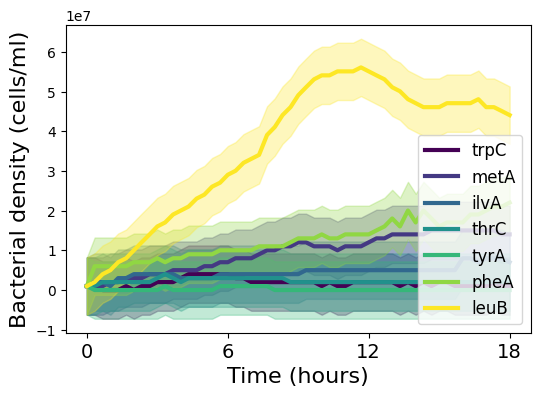


Loaded strains:
['M9_1X_trpC', 'M9_1X_metA', 'M9_1X_ilvA', 'M9_1X_thrC', 'M9_1X_tyrA', 'M9_1X_pheA', 'M9_1X_leuB']


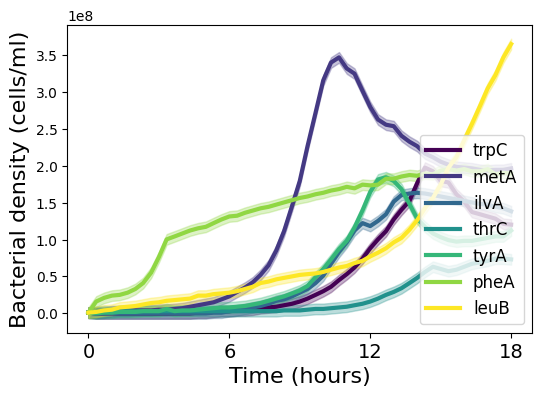


Loaded strains:
['M9_2X_trpC', 'M9_2X_metA', 'M9_2X_ilvA', 'M9_2X_thrC', 'M9_2X_tyrA', 'M9_2X_pheA', 'M9_2X_leuB']


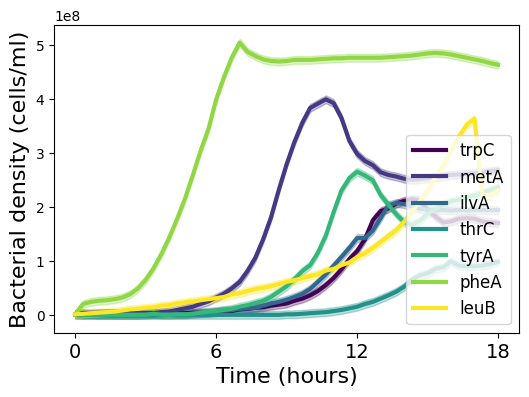


Loaded strains:
['M9_3X_trpC', 'M9_3X_metA', 'M9_3X_ilvA', 'M9_3X_thrC', 'M9_3X_tyrA', 'M9_3X_pheA', 'M9_3X_leuB']


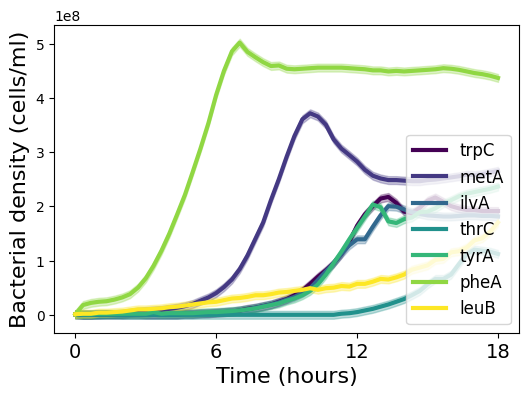


Loaded strains:
['M9_4X_trpC', 'M9_4X_metA', 'M9_4X_ilvA', 'M9_4X_thrC', 'M9_4X_tyrA', 'M9_4X_pheA', 'M9_4X_leuB']


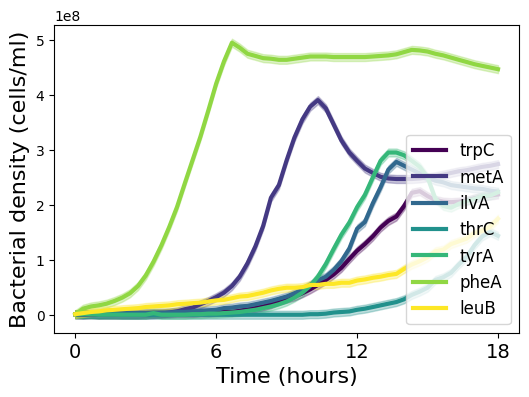

In [9]:
for X in X_values:
    X_strains, X_data = load_X_data(
        X=X,
        strain_lbls=strain_lbls,
        data_path=data_path,
        filename=csvfile,
        T=T
    )

    valid = [(s, d) for s, d in zip(X_strains, X_data) if d is not None]
    if len(valid) == 0:
        print(f"No valid data for X={X}")
        continue

    X_strains_valid, X_data_valid = zip(*valid)

    plot_od_data(X_data_valid, X_strains_valid, strain_colors, yscale='linear')

## Dose-response experiments

In [10]:


def generate_custom_colormap(zero_color=(0.9, 0.9, 0.9), base_color=(0., 0., 0.)):
    """
    Generate a custom colormap that varies from a given base color to gray.

    Parameters:
    - base_color: Tuple representing the RGB values of the base color.

    Returns:
    - cmap: Custom colormap object.
    """
    # Define the colors for the custom colormap
    colors = [zero_color, base_color]  # Base color and gray

    # Define the color map boundaries
    boundaries = [0, 1]

    # Generate the custom colormap
    cmap = LinearSegmentedColormap.from_list('custom_cmap', colors, N=256)

    return cmap


** Strain: M9_0X_trpC
** Strain: M9_1X_trpC
** Strain: M9_2X_trpC
** Strain: M9_3X_trpC
** Strain: M9_4X_trpC


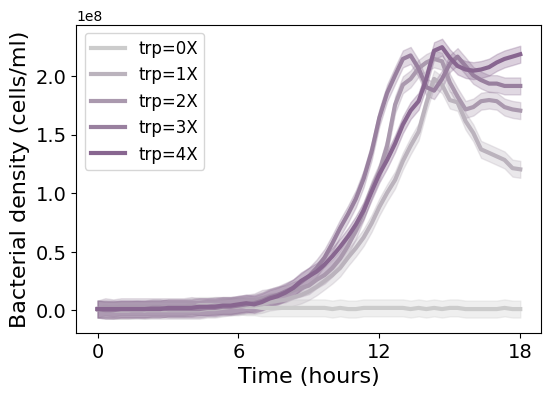

** Strain: M9_0X_metA
** Strain: M9_1X_metA
** Strain: M9_2X_metA
** Strain: M9_3X_metA
** Strain: M9_4X_metA


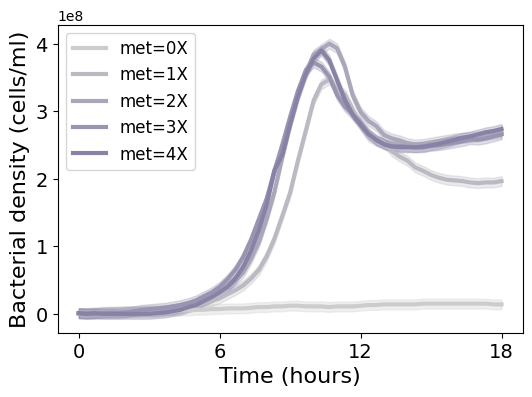

** Strain: M9_0X_ilvA
** Strain: M9_1X_ilvA
** Strain: M9_2X_ilvA
** Strain: M9_3X_ilvA
** Strain: M9_4X_ilvA


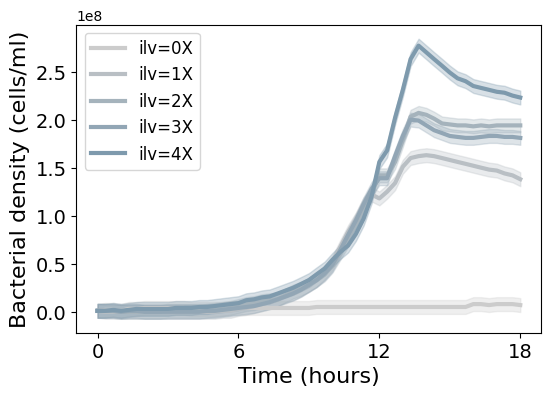

** Strain: M9_0X_thrC
** Strain: M9_1X_thrC
** Strain: M9_2X_thrC
** Strain: M9_3X_thrC
** Strain: M9_4X_thrC


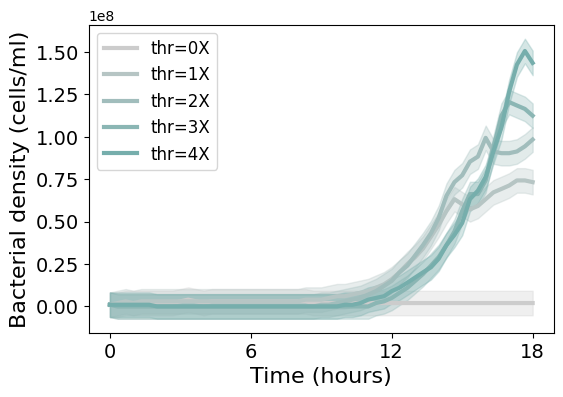

** Strain: M9_0X_tyrA
** Strain: M9_1X_tyrA
** Strain: M9_2X_tyrA
** Strain: M9_3X_tyrA
** Strain: M9_4X_tyrA


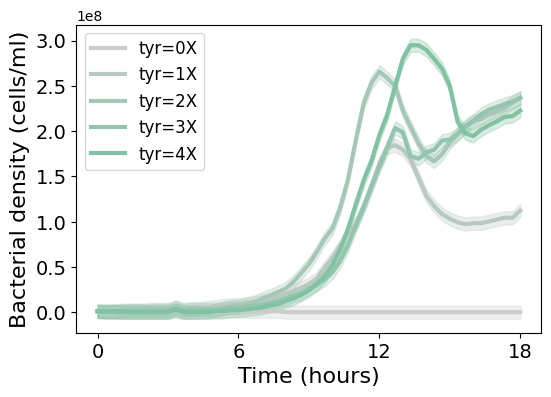

** Strain: M9_0X_pheA
** Strain: M9_1X_pheA
** Strain: M9_2X_pheA
** Strain: M9_3X_pheA
** Strain: M9_4X_pheA


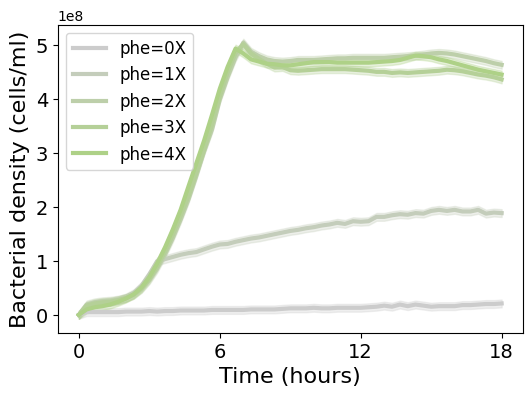

** Strain: M9_0X_leuB
** Strain: M9_1X_leuB
** Strain: M9_2X_leuB
** Strain: M9_3X_leuB
** Strain: M9_4X_leuB


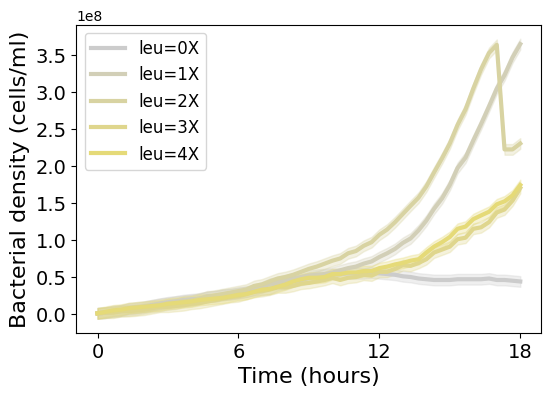

In [11]:


# Loop over each strain label
for i, this_strain in enumerate(strain_lbls):
    # Initialize lists to store all strains and all data
    all_strains = []
    all_data = []

    # Generate strain names using the template string and X_values
    for replacement_X in X_values:
        # Replace 'Y' with the desired string and 'X' with the current value
        strain_string = template_string.replace('Y', this_strain).replace('Z', str(replacement_X))
        all_strains.append(strain_string)

    # Load data for each strain and append it to all_data list
    for strain_name in all_strains:
        print("** Strain: %s" % strain_name)
        tab_name_data = 'OD'
        data = load_data(data_path=data_path,filename=csvfile, strain=strain_name, T=T)
        all_data.append(data)

    # Get the colormap
    cmap_aa = generate_custom_colormap((0.8, 0.8, 0.8), strain_colors[i])

    # Plot each strain separately with a gradient of blues
    plt.figure(figsize=(6, 4))  # Adjust figure size if needed
    for i, (data, strain) in enumerate(zip(all_data, all_strains)):
        # Extract data
        time = data['Time']
        mean_od = data[strain + ' MeanOD']
        std_od = data[strain + ' StdOD']

        # Calculate the standard error of the mean (SEM)
        sample_size = 3  # Adjust this if you have a different number of replicates
        sem = std_od / np.sqrt(sample_size)

        # Calculate the color based on the dose
        dose=int(strain[3])
        color = cmap_aa(dose / 8)
        #color = cmap_strains(i / len(all_strains))

        # Plot the data for the current strain
        sem = pd.to_numeric(sem)
        mean_od = pd.to_numeric(mean_od)

        plt.fill_between(time, mean_od - sem, mean_od + sem, color=color, alpha=0.3)

        # Plot the mean line with adjusted line properties
        plt.plot(time, mean_od, linestyle='-', linewidth=3, color=color, label="%s=%sX"%(strain[-4:-1], dose))

    plt.xlabel('Time (hours)', fontsize=16)
    plt.ylabel('Bacterial density (cells/ml)', fontsize=16)
    plt.legend(fontsize=12)
    plt.xticks(np.arange(0, time.iloc[-1]+1, 6))
    plt.yscale('linear')
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.grid(False)
    plt.show()

## Experimental Dose-Response

In [12]:

# Initialize lists to store all strains and all data
all_strains = []
all_data = []
all_aa = []

# Loop over each strain label
for this_strain in strain_lbls:
    # Generate strain names using the template string and X_values
    for replacement_X in X_values:
        # Replace 'Y' with the desired string and 'X' with the current value
        strain_string = template_string.replace('Y', this_strain).replace('Z', str(replacement_X))
        all_strains.append(strain_string)

        # Load data for each strain and append it to all_data list
        print("** Strain: %s" % strain_string)
        # Adjust the tab name to match your data
        tab_name_data = 'OD'
        data = load_data(data_path=data_path,filename=csvfile, strain=strain_string)
        all_data.append(data)
        all_aa.append(replacement_X)


** Strain: M9_0X_trpC
** Strain: M9_1X_trpC
** Strain: M9_2X_trpC
** Strain: M9_3X_trpC
** Strain: M9_4X_trpC
** Strain: M9_0X_metA
** Strain: M9_1X_metA
** Strain: M9_2X_metA
** Strain: M9_3X_metA
** Strain: M9_4X_metA
** Strain: M9_0X_ilvA
** Strain: M9_1X_ilvA
** Strain: M9_2X_ilvA
** Strain: M9_3X_ilvA
** Strain: M9_4X_ilvA
** Strain: M9_0X_thrC
** Strain: M9_1X_thrC
** Strain: M9_2X_thrC
** Strain: M9_3X_thrC
** Strain: M9_4X_thrC
** Strain: M9_0X_tyrA
** Strain: M9_1X_tyrA
** Strain: M9_2X_tyrA
** Strain: M9_3X_tyrA
** Strain: M9_4X_tyrA
** Strain: M9_0X_pheA
** Strain: M9_1X_pheA
** Strain: M9_2X_pheA
** Strain: M9_3X_pheA
** Strain: M9_4X_pheA
** Strain: M9_0X_leuB
** Strain: M9_1X_leuB
** Strain: M9_2X_leuB
** Strain: M9_3X_leuB
** Strain: M9_4X_leuB


In [13]:
def get_density_at_T(data, strain, T):
    col = f"{strain} MeanOD"

    df = data[["Time", col]].copy()
    df = df.dropna(subset=["Time", col])

    # Keep only times up to T
    df = df[df["Time"] <= T]

    if len(df) == 0:
        return np.nan

    # Use the last valid value before or at T
    return df.sort_values("Time")[col].iloc[-1]

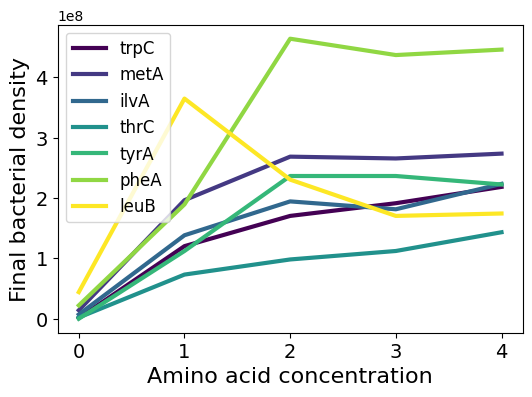

In [14]:

# Get the Blues colormap
cmap_strains = plt.get_cmap('Blues')
# Initialize lists to store concentration and density values
concentrations = []
densities = []


plt.figure(figsize=(6, 4))

current_label = None
concentrations = []
densities = []

for data, strain, aa in zip(all_data, all_strains, all_aa):
    strain_label = strain[-4:]
    density_at_endpoint = get_density_at_T(data, strain, T)

    # If this is a new strain, plot the previous one
    if current_label is not None and strain_label != current_label:
        istrain = strain_lbls.index(current_label)
        plt.plot(
            concentrations,
            densities,
            linestyle='-',
            lw=3,
            label=current_label,
            color=strain_colors[istrain]
        )

        concentrations = []
        densities = []


    concentrations.append(aa)
    densities.append(density_at_endpoint)
    current_label = strain_label

# Plot the final strain group
if len(concentrations) > 0:
    istrain = strain_lbls.index(current_label)
    plt.plot(
        concentrations,
        densities,
        linestyle='-',
        lw=3,
        label=current_label,
        color=strain_colors[istrain]
    )

plt.xlabel('Amino acid concentration', fontsize=16)
plt.ylabel('Final bacterial density', fontsize=16)
plt.legend(fontsize=12)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xticks([0, 1, 2, 3, 4])
plt.show()



## Model parametrization

In [15]:
def print_fit_results(mu_est, rho_est):
    print("Estimated Parameters:")
    print(f"mu (max growth rate): {mu_est:.4e}")
    print(f"rho (yield): {rho_est:.4e}")

def model_fit(t, rho, muK, strain, data):
    initial_R = 1.0
    initial_B = data[f"{strain} MeanOD"].iloc[0]
    y0 = [initial_R, initial_B]

    out = simulate_model(rho, muK, y0, t)

    if isinstance(out, tuple) and len(out) == 2:
        _, B = out
    else:
        B = out

    B = np.asarray(B, dtype=float).ravel()

    return B


In [16]:
def plot_od_sim(df, strain, popt, yscale='linear'):
    """
    Plot experimental OD-derived density and model prediction side-by-side,
    sharing the y-axis.
    """

    time = pd.to_numeric(df['Time'], errors='coerce')
    mean_od = pd.to_numeric(df[strain + ' MeanOD'], errors='coerce')
    std_od = pd.to_numeric(df[strain + ' StdOD'], errors='coerce')

    sample_size = 3
    sem = std_od / np.sqrt(sample_size)

    valid = time.notna() & mean_od.notna() & sem.notna()
    time = time[valid].to_numpy()
    mean_od = mean_od[valid].to_numpy()
    sem = sem[valid].to_numpy()

    initial_conditions = [1.0, mean_od[0]]
    simulated_t, simulated_B = simulate_model(*popt, initial_conditions, time)

    istrain = strain_lbls.index(strain[-4:])
    #color = strain_colors[istrain]

    strain_label = get_strain_label(strain)
    color = strain_color_map[strain_label]

    lower = mean_od - sem
    upper = mean_od + sem

    fig, axes = plt.subplots(
        1, 2,
        figsize=(7, 2.4),
        sharey=True,
        constrained_layout=True
    )

    axes[0].fill_between(
        time,
        lower,
        upper,
        color=color,
        alpha=0.35,
        linewidth=0
    )

    axes[0].plot(
        time,
        mean_od,
        linestyle='-',
        color=color,
        lw=3,
        label=r'$\Delta$%s'%strain_label
    )

    axes[1].plot(
        simulated_t,
        simulated_B,
        linestyle='-',
        color=color,
        lw=3
    )

    # Dynamic y-limits based on data + model
    y_min = np.nanmin([0, lower.min(), simulated_B.min()])
    y_max = np.nanmax([1e8, upper.max(), simulated_B.max()])
    pad = 0.08 * (y_max - y_min)

    for ax in axes:
        ax.set_yscale(yscale)
        ax.set_ylim(y_min - pad, y_max + pad)
        ax.set_xlabel('Time (hours)')
        ax.grid(False)
        ax.legend()

    #axes[0].set_title('Data')
    axes[0].set_ylabel('Density (cells/ml)')
    #axes[1].set_title('Model')

    #fig.suptitle(strain)

In [17]:
def fit_strains_for_x_value(
    x_value,
    strain_lbls,
    T,
    beta_default,
    Ki_default,
    template_string="M9_ZX_Y",
    tab_name_data="OD",
    plot=True
):
    filtered_strains = []

    for this_strain in strain_lbls:
        strain_string = (
            template_string
            .replace("Y", this_strain)
            .replace("Z", str(x_value))
        )
        filtered_strains.append(strain_string)

    print("Filtered strains:")
    print(filtered_strains)

    strains_parameters = []

    for strain_name in filtered_strains:
        print(f"\n\n** Strain: {strain_name}")

        data = load_data(data_path=data_path,filename=csvfile, strain=strain_name, T=T)

        if data is None:
            continue

        time = data["Time"].values
        mean_od = data[f"{strain_name} MeanOD"].values

        try:
            # Active method: curve_fit
            rho0 = 1e8 #initial guess
            muK0 = 1e-10

            popt, pcov = curve_fit(
                lambda t, rho, muK: model_fit(t, rho, muK, strain_name, data),
                time,
                mean_od,
                p0=[rho0, muK0],
                bounds=([0, 0], [np.inf, np.inf]),
                maxfev=10000
            )

            rho, muK = popt
            print_fit_results(muK, rho)

            strains_parameters.append({
                "parameters": [muK, 1, rho, beta_default, Ki_default],
                "name": strain_name
            })

            if plot:
                plot_od_sim(data, strain_name, popt, yscale="linear")

                outfile = figures_path / f"fit-strain-{strain_name}.pdf"
                print(f"Exporting to {outfile}")
                plt.savefig(outfile, dpi=300, bbox_inches="tight")
                plt.show()

        except Exception as e:
            print(f"An error occurred while fitting strain {strain_name}: {e}")
            #plot_od_data([data], [strain_name], colors)

    print("\nFinal strain parameters:")
    print(strains_parameters)
    print(f"\nNumber of fitted strains: {len(strains_parameters)}")

    return strains_parameters

In [18]:
strain_colors = ["#177E89", "#A52B29", "#FF6B6B", "#FFBB5F", "#00A6A6", "#362847", "#7C8838"]
strain_lbls = ['trpC', 'metA', 'ilvA', 'thrC', 'tyrA', 'pheA', 'leuB']

strain_color_map = dict(zip(strain_lbls, strain_colors))

def get_strain_label(strain_name, strain_lbls=strain_lbls):
    for lbl in strain_lbls:
        if lbl in strain_name:
            return lbl
    raise ValueError(f"Could not find strain label in strain name: {strain_name}")

In [19]:
print(X_values)

[0, 1, 2, 3, 4]



=== Fitting X = 0 ===
Filtered strains:
['M9_0X_trpC', 'M9_0X_metA', 'M9_0X_ilvA', 'M9_0X_thrC', 'M9_0X_tyrA', 'M9_0X_pheA', 'M9_0X_leuB']


** Strain: M9_0X_trpC
Estimated Parameters:
mu (max growth rate): 9.6385e+05
rho (yield): 8.1714e+05
Exporting to /content/profileX/figures/fit-strain-M9_0X_trpC.pdf


/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


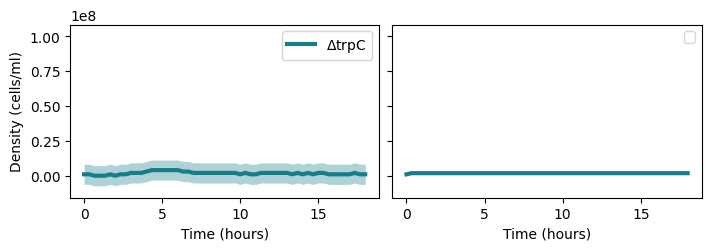



** Strain: M9_0X_metA
Estimated Parameters:
mu (max growth rate): 3.1028e-09
rho (yield): 1.1250e+08
Exporting to /content/profileX/figures/fit-strain-M9_0X_metA.pdf


/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


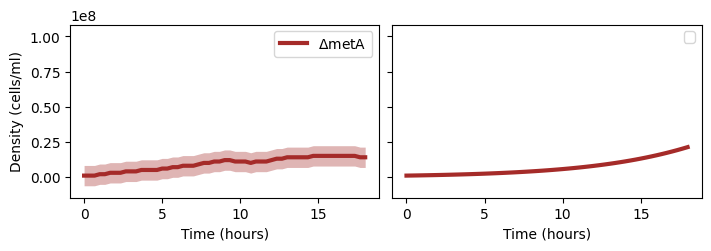



** Strain: M9_0X_ilvA
Estimated Parameters:
mu (max growth rate): 2.5367e-09
rho (yield): 9.8438e+07
Exporting to /content/profileX/figures/fit-strain-M9_0X_ilvA.pdf


/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


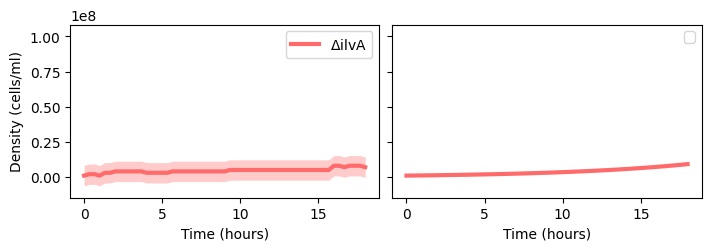



** Strain: M9_0X_thrC
Estimated Parameters:
mu (max growth rate): 1.1632e-09
rho (yield): 9.7917e+07
Exporting to /content/profileX/figures/fit-strain-M9_0X_thrC.pdf


/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


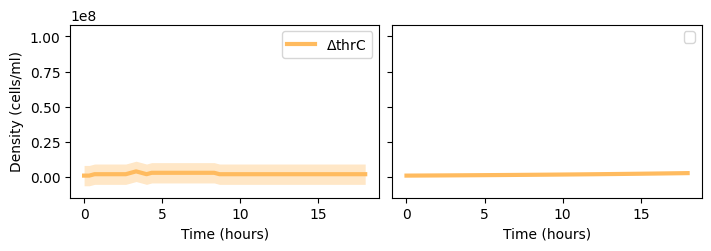



** Strain: M9_0X_tyrA
Estimated Parameters:
mu (max growth rate): 6.4149e-16
rho (yield): 5.4308e+02
Exporting to /content/profileX/figures/fit-strain-M9_0X_tyrA.pdf


/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


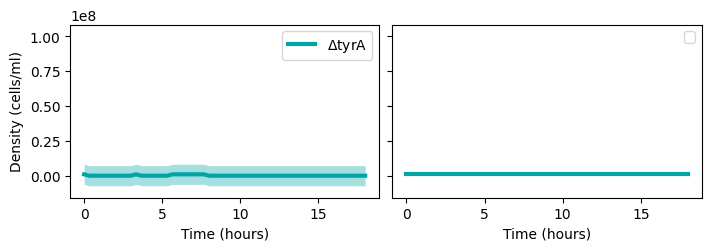



** Strain: M9_0X_pheA
Estimated Parameters:
mu (max growth rate): 3.4242e-09
rho (yield): 1.2656e+08
Exporting to /content/profileX/figures/fit-strain-M9_0X_pheA.pdf


/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


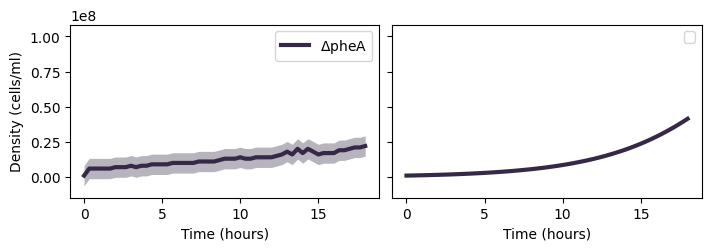



** Strain: M9_0X_leuB
Estimated Parameters:
mu (max growth rate): 2.9170e-08
rho (yield): 4.8495e+07
Exporting to /content/profileX/figures/fit-strain-M9_0X_leuB.pdf


/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


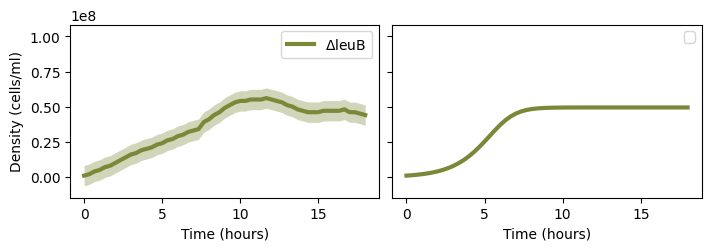


Final strain parameters:
[{'parameters': [np.float64(963853.2494680549), 1, np.float64(817139.0825884963), 2e-10, 100000000000.0], 'name': 'M9_0X_trpC'}, {'parameters': [np.float64(3.1027951035911974e-09), 1, np.float64(112500000.0), 2e-10, 100000000000.0], 'name': 'M9_0X_metA'}, {'parameters': [np.float64(2.5366831807546084e-09), 1, np.float64(98437500.0), 2e-10, 100000000000.0], 'name': 'M9_0X_ilvA'}, {'parameters': [np.float64(1.163162144937419e-09), 1, np.float64(97916674.61395264), 2e-10, 100000000000.0], 'name': 'M9_0X_thrC'}, {'parameters': [np.float64(6.414873362924908e-16), 1, np.float64(543.0832044356503), 2e-10, 100000000000.0], 'name': 'M9_0X_tyrA'}, {'parameters': [np.float64(3.4242357177243055e-09), 1, np.float64(126562500.0), 2e-10, 100000000000.0], 'name': 'M9_0X_pheA'}, {'parameters': [np.float64(2.917033594925582e-08), 1, np.float64(48494923.50007075), 2e-10, 100000000000.0], 'name': 'M9_0X_leuB'}]

Number of fitted strains: 7

=== Fitting X = 1 ===
Filtered strains:

/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


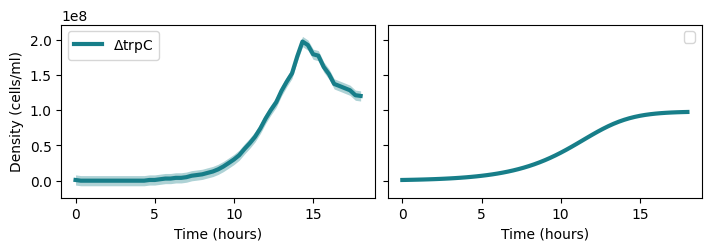



** Strain: M9_1X_metA
Estimated Parameters:
mu (max growth rate): 8.4922e-09
rho (yield): 1.6779e+08
Exporting to /content/profileX/figures/fit-strain-M9_1X_metA.pdf


/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


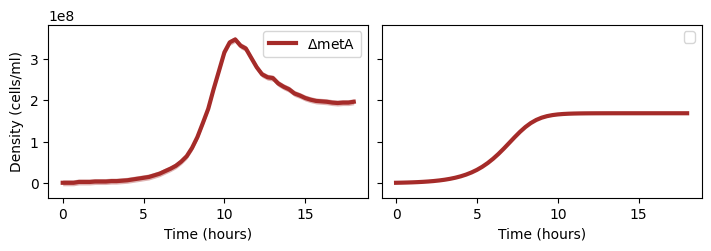



** Strain: M9_1X_ilvA
Estimated Parameters:
mu (max growth rate): 8.6325e-09
rho (yield): 1.0198e+08
Exporting to /content/profileX/figures/fit-strain-M9_1X_ilvA.pdf


/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


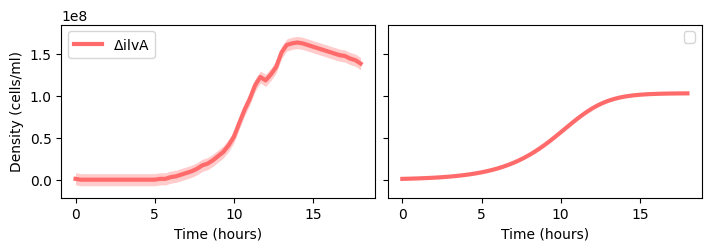



** Strain: M9_1X_thrC
Estimated Parameters:
mu (max growth rate): 4.6075e-09
rho (yield): 1.2500e+08
Exporting to /content/profileX/figures/fit-strain-M9_1X_thrC.pdf


/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


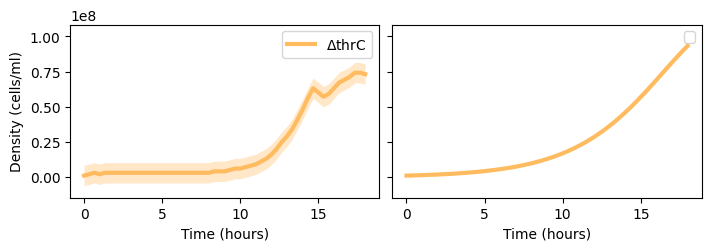



** Strain: M9_1X_tyrA
Estimated Parameters:
mu (max growth rate): 9.1751e-09
rho (yield): 9.7848e+07
Exporting to /content/profileX/figures/fit-strain-M9_1X_tyrA.pdf


/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


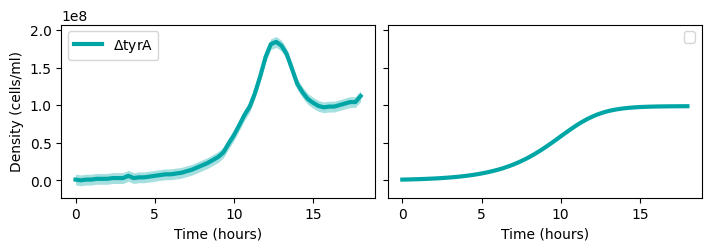



** Strain: M9_1X_pheA
Estimated Parameters:
mu (max growth rate): 2.0043e-08
rho (yield): 1.5978e+08
Exporting to /content/profileX/figures/fit-strain-M9_1X_pheA.pdf


/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


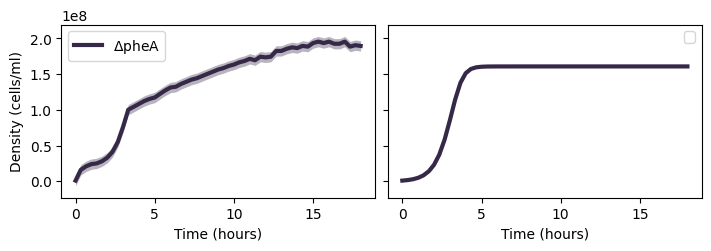



** Strain: M9_1X_leuB
Estimated Parameters:
mu (max growth rate): 5.0085e-09
rho (yield): 1.5797e+08


/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Exporting to /content/profileX/figures/fit-strain-M9_1X_leuB.pdf


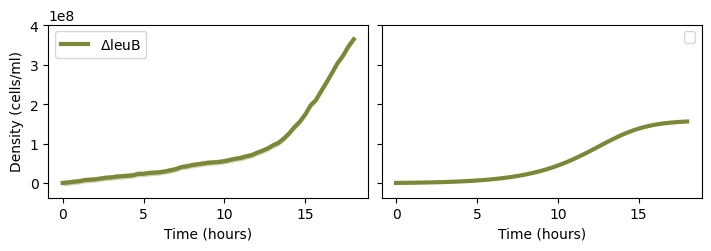


Final strain parameters:
[{'parameters': [np.float64(8.05338265599466e-09), 1, np.float64(97177615.18494803), 2e-10, 100000000000.0], 'name': 'M9_1X_trpC'}, {'parameters': [np.float64(8.4922382071678e-09), 1, np.float64(167789641.22935045), 2e-10, 100000000000.0], 'name': 'M9_1X_metA'}, {'parameters': [np.float64(8.63249355037758e-09), 1, np.float64(101976279.8765756), 2e-10, 100000000000.0], 'name': 'M9_1X_ilvA'}, {'parameters': [np.float64(4.6075049041176265e-09), 1, np.float64(125000000.0), 2e-10, 100000000000.0], 'name': 'M9_1X_thrC'}, {'parameters': [np.float64(9.175061485709078e-09), 1, np.float64(97848357.46084449), 2e-10, 100000000000.0], 'name': 'M9_1X_tyrA'}, {'parameters': [np.float64(2.0042731059278314e-08), 1, np.float64(159782862.83759004), 2e-10, 100000000000.0], 'name': 'M9_1X_pheA'}, {'parameters': [np.float64(5.008534701600923e-09), 1, np.float64(157968886.16796547), 2e-10, 100000000000.0], 'name': 'M9_1X_leuB'}]

Number of fitted strains: 7

=== Fitting X = 2 ===
Fi

/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


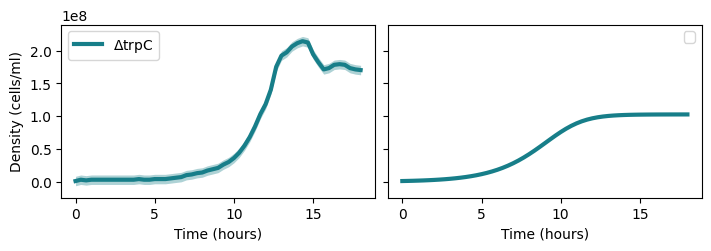



** Strain: M9_2X_metA
Estimated Parameters:
mu (max growth rate): 8.7340e-09
rho (yield): 2.0029e+08
Exporting to /content/profileX/figures/fit-strain-M9_2X_metA.pdf


/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


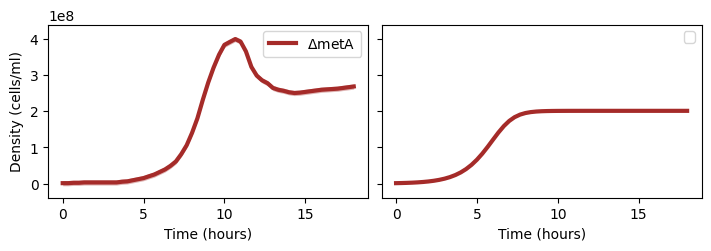



** Strain: M9_2X_ilvA
Estimated Parameters:
mu (max growth rate): 9.5202e-09
rho (yield): 1.0643e+08
Exporting to /content/profileX/figures/fit-strain-M9_2X_ilvA.pdf


/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


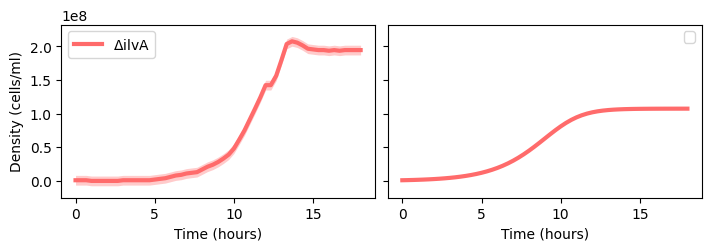



** Strain: M9_2X_thrC
Estimated Parameters:
mu (max growth rate): 5.4812e-09
rho (yield): 1.2500e+08
Exporting to /content/profileX/figures/fit-strain-M9_2X_thrC.pdf


/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


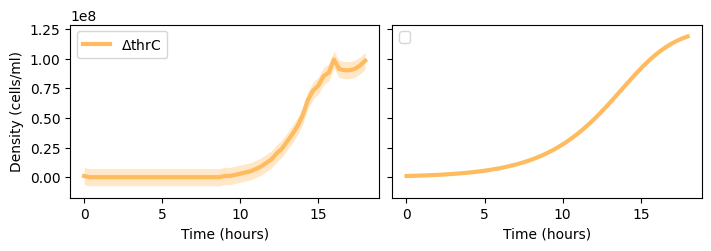



** Strain: M9_2X_tyrA
Estimated Parameters:
mu (max growth rate): 6.7801e-09
rho (yield): 1.5578e+08
Exporting to /content/profileX/figures/fit-strain-M9_2X_tyrA.pdf


/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


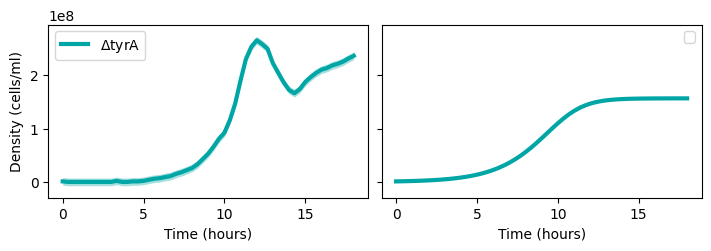



** Strain: M9_2X_pheA
Estimated Parameters:
mu (max growth rate): 5.2319e-09
rho (yield): 4.7343e+08
Exporting to /content/profileX/figures/fit-strain-M9_2X_pheA.pdf


/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


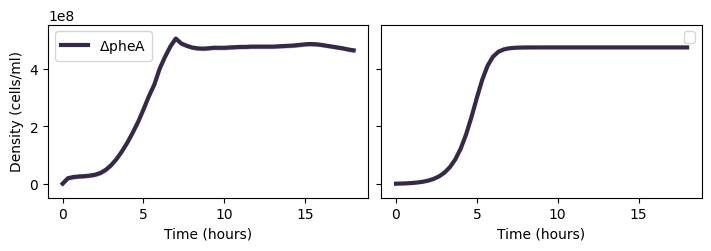



** Strain: M9_2X_leuB
Estimated Parameters:
mu (max growth rate): 7.5823e-09
rho (yield): 1.3998e+08
Exporting to /content/profileX/figures/fit-strain-M9_2X_leuB.pdf


/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


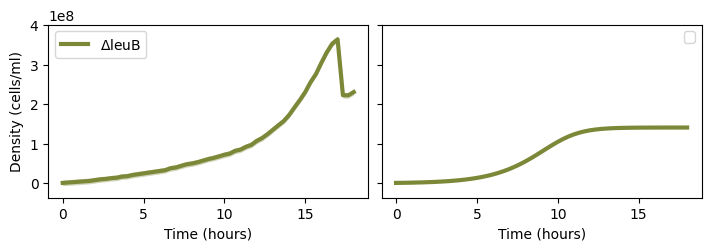


Final strain parameters:
[{'parameters': [np.float64(9.76309317809945e-09), 1, np.float64(101720001.15780932), 2e-10, 100000000000.0], 'name': 'M9_2X_trpC'}, {'parameters': [np.float64(8.733988749877921e-09), 1, np.float64(200291501.32870936), 2e-10, 100000000000.0], 'name': 'M9_2X_metA'}, {'parameters': [np.float64(9.520246969928336e-09), 1, np.float64(106425092.39619754), 2e-10, 100000000000.0], 'name': 'M9_2X_ilvA'}, {'parameters': [np.float64(5.4811558016608575e-09), 1, np.float64(125000000.0), 2e-10, 100000000000.0], 'name': 'M9_2X_thrC'}, {'parameters': [np.float64(6.780137655673394e-09), 1, np.float64(155781342.7770342), 2e-10, 100000000000.0], 'name': 'M9_2X_tyrA'}, {'parameters': [np.float64(5.2318943818369645e-09), 1, np.float64(473425274.7449011), 2e-10, 100000000000.0], 'name': 'M9_2X_pheA'}, {'parameters': [np.float64(7.582331428277311e-09), 1, np.float64(139983148.45353332), 2e-10, 100000000000.0], 'name': 'M9_2X_leuB'}]

Number of fitted strains: 7

=== Fitting X = 3 ==

/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


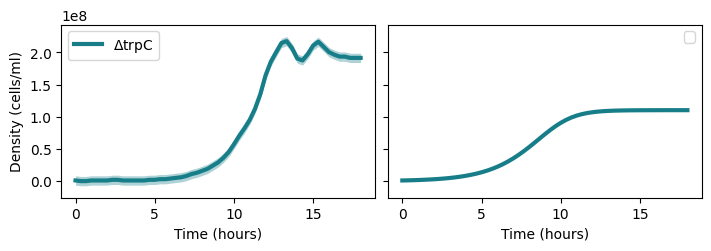



** Strain: M9_3X_metA
Estimated Parameters:
mu (max growth rate): 8.6128e-09
rho (yield): 1.9909e+08


/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Exporting to /content/profileX/figures/fit-strain-M9_3X_metA.pdf


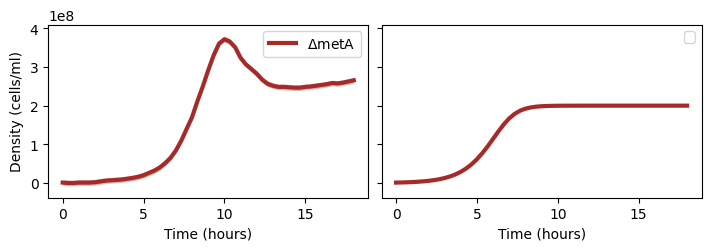



** Strain: M9_3X_ilvA
Estimated Parameters:
mu (max growth rate): 9.2700e-09
rho (yield): 1.0422e+08
Exporting to /content/profileX/figures/fit-strain-M9_3X_ilvA.pdf


/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


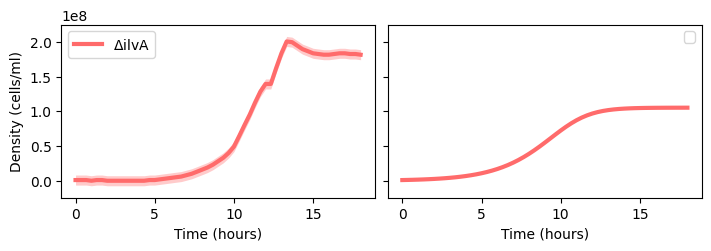



** Strain: M9_3X_thrC
Estimated Parameters:
mu (max growth rate): 4.7321e-09
rho (yield): 1.2500e+08
Exporting to /content/profileX/figures/fit-strain-M9_3X_thrC.pdf


/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


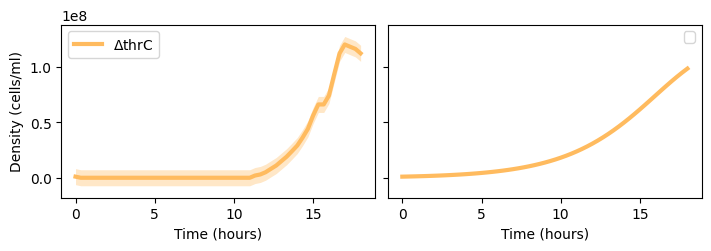



** Strain: M9_3X_tyrA
Estimated Parameters:
mu (max growth rate): 1.0050e-08
rho (yield): 1.0907e+08
Exporting to /content/profileX/figures/fit-strain-M9_3X_tyrA.pdf


/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


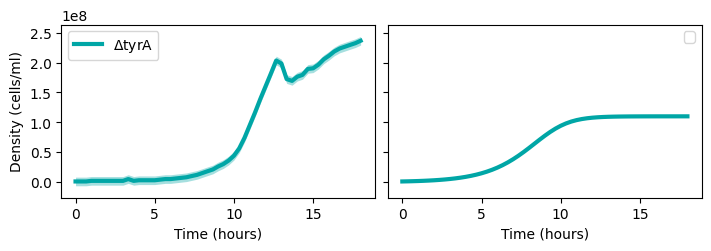



** Strain: M9_3X_pheA
Estimated Parameters:
mu (max growth rate): 5.0487e-09
rho (yield): 4.6720e+08
Exporting to /content/profileX/figures/fit-strain-M9_3X_pheA.pdf


/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


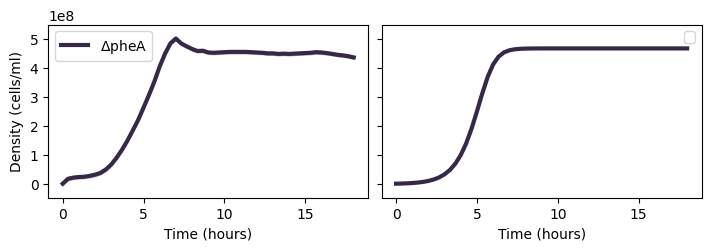



** Strain: M9_3X_leuB
Estimated Parameters:
mu (max growth rate): 1.2511e-08
rho (yield): 8.2602e+07
Exporting to /content/profileX/figures/fit-strain-M9_3X_leuB.pdf


/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


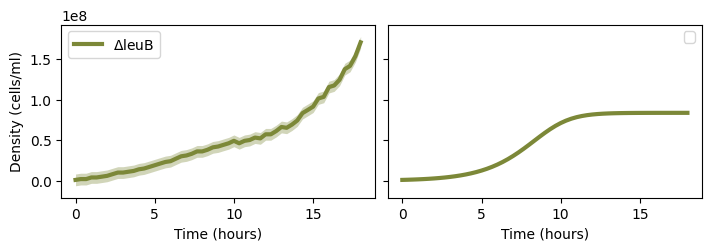


Final strain parameters:
[{'parameters': [np.float64(9.76416916643836e-09), 1, np.float64(109242815.06513351), 2e-10, 100000000000.0], 'name': 'M9_3X_trpC'}, {'parameters': [np.float64(8.612760183172665e-09), 1, np.float64(199087925.66692764), 2e-10, 100000000000.0], 'name': 'M9_3X_metA'}, {'parameters': [np.float64(9.269995144526808e-09), 1, np.float64(104222396.3465022), 2e-10, 100000000000.0], 'name': 'M9_3X_ilvA'}, {'parameters': [np.float64(4.732133832280209e-09), 1, np.float64(125000000.0), 2e-10, 100000000000.0], 'name': 'M9_3X_thrC'}, {'parameters': [np.float64(1.0050028321562964e-08), 1, np.float64(109068674.48856676), 2e-10, 100000000000.0], 'name': 'M9_3X_tyrA'}, {'parameters': [np.float64(5.0486857738166385e-09), 1, np.float64(467200917.3090891), 2e-10, 100000000000.0], 'name': 'M9_3X_pheA'}, {'parameters': [np.float64(1.2511016997620816e-08), 1, np.float64(82602274.49106564), 2e-10, 100000000000.0], 'name': 'M9_3X_leuB'}]

Number of fitted strains: 7

=== Fitting X = 4 ==

/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


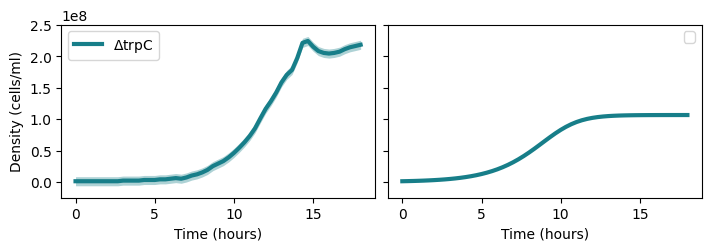



** Strain: M9_4X_metA
Estimated Parameters:
mu (max growth rate): 8.1034e-09
rho (yield): 1.9818e+08
Exporting to /content/profileX/figures/fit-strain-M9_4X_metA.pdf


/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


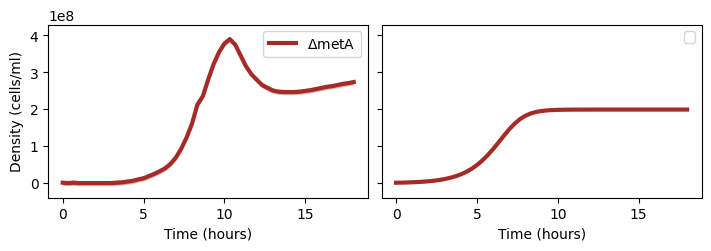



** Strain: M9_4X_ilvA
Estimated Parameters:
mu (max growth rate): 7.2579e-09
rho (yield): 1.2870e+08
Exporting to /content/profileX/figures/fit-strain-M9_4X_ilvA.pdf


/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


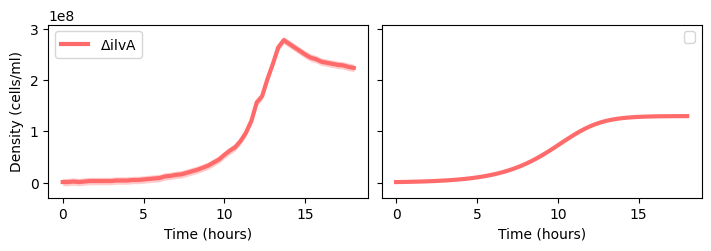



** Strain: M9_4X_thrC
Estimated Parameters:
mu (max growth rate): 5.1707e-09
rho (yield): 1.2500e+08


/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Exporting to /content/profileX/figures/fit-strain-M9_4X_thrC.pdf


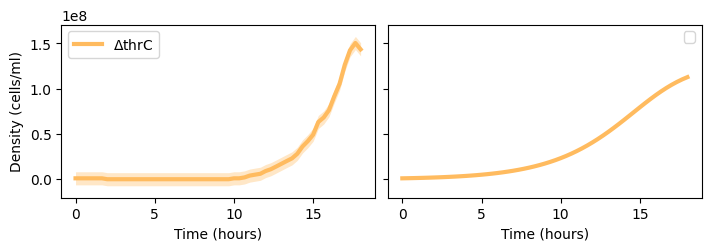



** Strain: M9_4X_tyrA
Estimated Parameters:
mu (max growth rate): 6.0119e-09
rho (yield): 1.4872e+08
Exporting to /content/profileX/figures/fit-strain-M9_4X_tyrA.pdf


/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


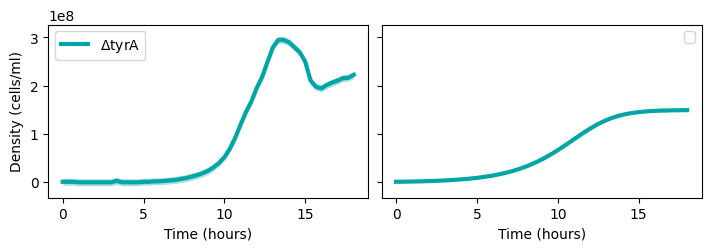



** Strain: M9_4X_pheA
Estimated Parameters:
mu (max growth rate): 4.5441e-09
rho (yield): 4.7973e+08
Exporting to /content/profileX/figures/fit-strain-M9_4X_pheA.pdf


/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


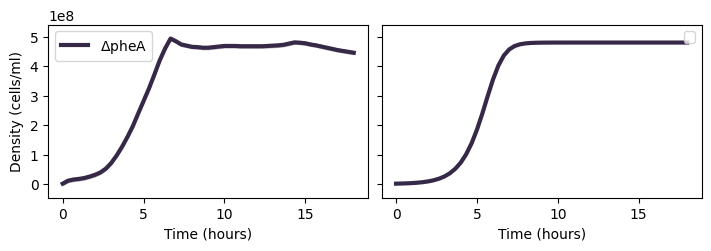



** Strain: M9_4X_leuB
Estimated Parameters:
mu (max growth rate): 6.5772e-09
rho (yield): 1.0912e+08
Exporting to /content/profileX/figures/fit-strain-M9_4X_leuB.pdf


/tmp/ipykernel_80635/829670316.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


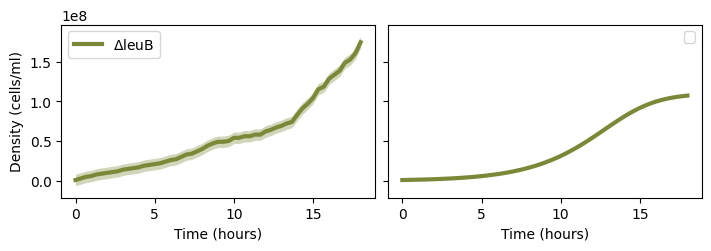


Final strain parameters:
[{'parameters': [np.float64(9.732072881495583e-09), 1, np.float64(105554386.31895842), 2e-10, 100000000000.0], 'name': 'M9_4X_trpC'}, {'parameters': [np.float64(8.10336519319044e-09), 1, np.float64(198182634.0661296), 2e-10, 100000000000.0], 'name': 'M9_4X_metA'}, {'parameters': [np.float64(7.257933536437527e-09), 1, np.float64(128697881.20775463), 2e-10, 100000000000.0], 'name': 'M9_4X_ilvA'}, {'parameters': [np.float64(5.170735494751238e-09), 1, np.float64(125000000.0), 2e-10, 100000000000.0], 'name': 'M9_4X_thrC'}, {'parameters': [np.float64(6.0119316962251655e-09), 1, np.float64(148723724.38893777), 2e-10, 100000000000.0], 'name': 'M9_4X_tyrA'}, {'parameters': [np.float64(4.544130794085605e-09), 1, np.float64(479728829.9766586), 2e-10, 100000000000.0], 'name': 'M9_4X_pheA'}, {'parameters': [np.float64(6.577240789373286e-09), 1, np.float64(109117870.3385276), 2e-10, 100000000000.0], 'name': 'M9_4X_leuB'}]

Number of fitted strains: 7

Saved combined paramet

In [20]:


all_strains_parameters = {}

for X in X_values:
    print(f"\n=== Fitting X = {X} ===")

    strains_parameters = fit_strains_for_x_value(
        x_value=X,
        strain_lbls=strain_lbls,
        T=T,
        beta_default=betax,
        Ki_default=Kix,
        plot=True
    )

    all_strains_parameters[X] = strains_parameters


# Save combined file
combined_output_file = data_path / "strains_parameters.pkl"
with open(combined_output_file, "wb") as f:
    pickle.dump(all_strains_parameters, f)
print(f"\nSaved combined parameter dictionary to {combined_output_file}")
